# Parte VI -- Reduccion de Dimensionalidad

Corre en la **misma carpeta del Workspace** que la Parte I: reutiliza sus modulos y los parquet de `artifacts/`.

In [0]:
import sys, os, importlib.util

src = os.getcwd()
sys.path.insert(0, src)

def load_mod(name):
    path = os.path.join(src, name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero la Parte I en esta carpeta'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

config = load_mod('config')
preprocessing = load_mod('preprocessing')
cleaning = load_mod('cleaning')
print('Artefactos en:', config.ARTIFACTS)

clean = cleaning.clean_subset(preprocessing.build_subset())

Trabajamos sobre dos representaciones de los negocios de la muestra:

1. **PCA desde cero** sobre la matriz de features de la Parte III (~28 dimensiones: 10 continuas + 18 categorias binarias): estandarizacion -> matriz de covarianza -> eigendescomposicion -> seleccion de componentes que expliquen 90%+ de varianza -> proyeccion 2D/3D e interpretacion de loadings.
2. **SVD** sobre la matriz TF-IDF de las resenas (negocios x 2,000 terminos): los factores singulares emergen como *temas latentes*, y la version truncada nos da compresion con error de reconstruccion medible.

La celda siguiente re-escribe `features.py` tal cual se uso en la Parte III, para construir exactamente la misma matriz.

In [0]:
%%writefile features.py
import numpy as np
import pandas as pd
from collections import Counter


def _behavioral(reviews):
    ref = reviews['date'].max()
    agg = reviews.groupby('business_id').agg(
        rating_std=('stars', 'std'),
        first_review=('date', 'min'),
        avg_review_length=('text_len', 'mean'),
    ).reset_index()
    agg['rating_std'] = agg['rating_std'].fillna(0.0)
    agg['business_age_years'] = (ref - agg['first_review']).dt.days / 365.25
    return agg[['business_id', 'rating_std', 'business_age_years', 'avg_review_length']]


def build_business_features(clean, top_categories=18, cat_weight=1.0):
    biz = clean['business'].copy().reset_index(drop=True)

    chk = clean['checkins']
    if 'n_checkins' in chk.columns:
        biz = biz.merge(chk[['business_id', 'n_checkins']], on='business_id', how='left')
    if 'n_checkins' not in biz.columns:
        biz['n_checkins'] = 0
    biz['n_checkins'] = biz['n_checkins'].fillna(0)

    biz = biz.merge(_behavioral(clean['reviews']), on='business_id', how='left')
    for col in ('rating_std', 'business_age_years', 'avg_review_length'):
        biz[col] = biz[col].fillna(0.0)

    pr_med = biz['price_range'].median()
    biz['price_range_imp'] = biz['price_range'].fillna(pr_med)

    cont = pd.DataFrame({
        'stars':         biz['stars'].astype(float),
        'log_reviews':   np.log1p(biz['review_count'].astype(float)),
        'price_range':   biz['price_range_imp'].astype(float),
        'n_categories':  biz['n_categories'].astype(float),
        'n_days_open':   biz['n_days_open'].astype(float),
        'log_checkins':  np.log1p(biz['n_checkins'].astype(float)),
        'is_open':       biz['is_open'].astype(float),
        'rating_std':    biz['rating_std'].astype(float),
        'business_age':  biz['business_age_years'].astype(float),
        'avg_rev_len':   biz['avg_review_length'].astype(float),
    })

    cat_counts = Counter()
    for lst in biz['categories_list']:
        cat_counts.update(lst)
    top = [c for c, _ in cat_counts.most_common(top_categories)]
    cat_mat = pd.DataFrame(
        {f'cat::{c}': biz['categories_list'].apply(lambda l, c=c: 1.0 if c in l else 0.0)
         for c in top}
    )

    feat = pd.concat([cont, cat_mat], axis=1)
    names = list(feat.columns)

    X = feat.to_numpy(dtype=float)
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd[sd == 0] = 1.0
    Xz = (X - mu) / sd

    if cat_weight != 1.0:
        cat_cols = [i for i, n in enumerate(names) if n.startswith('cat::')]
        Xz[:, cat_cols] *= cat_weight

    return Xz, names, biz['business_id'].to_numpy(), biz

Overwriting features.py


In [0]:
%%writefile dimensionality_reduction.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# PCA desde cero
def pca_fit(Xz):
    n = Xz.shape[0]
    cov = (Xz.T @ Xz) / (n - 1)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = np.maximum(eigvals[order], 0.0)
    eigvecs = eigvecs[:, order]
    evr = eigvals / eigvals.sum()
    return eigvals, eigvecs, evr


def n_components_for(evr, target=0.90):
    cum = np.cumsum(evr)
    k = int(np.searchsorted(cum, target) + 1)
    print(f'{k} componentes explican {cum[k-1]:.1%} de la varianza '
          f'(objetivo {target:.0%}, de {len(evr)} dims originales)')
    return k


def plot_scree(evr, target=0.90):
    cum = np.cumsum(evr)
    k = int(np.searchsorted(cum, target) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].bar(range(1, len(evr) + 1), evr, color='#378ADD')
    ax[0].set_xlabel('componente'); ax[0].set_ylabel('varianza explicada')
    ax[0].set_title('Scree plot')
    ax[1].plot(range(1, len(evr) + 1), cum, 'o-', color='#D85A30', ms=3)
    ax[1].axhline(target, ls='--', color='gray', alpha=0.7)
    ax[1].axvline(k, ls='--', color='gray', alpha=0.7)
    ax[1].set_xlabel('componentes'); ax[1].set_ylabel('varianza acumulada')
    ax[1].set_title(f'{k} PCs alcanzan {target:.0%}')
    plt.tight_layout(); plt.show()
    return k


def pca_project(Xz, eigvecs, k):
    return Xz @ eigvecs[:, :k]


def loadings_table(eigvecs, evr, feat_names, n_pc=4, top=6):
    """Variables que mas pesan (|loading|) en cada componente principal."""
    rows = []
    for j in range(n_pc):
        v = eigvecs[:, j]
        idx = np.argsort(-np.abs(v))[:top]
        rows.append({
            'PC': f'PC{j+1}',
            'var_explicada': f'{evr[j]:.1%}',
            'top_variables': ', '.join(f'{feat_names[i]} ({v[i]:+.2f})' for i in idx),
        })
    return pd.DataFrame(rows)


def plot_projection(P, color, color_label, evr):
    fig = plt.figure(figsize=(13, 5.5))
    ax0 = fig.add_subplot(1, 2, 1)
    sc = ax0.scatter(P[:, 0], P[:, 1], c=color, cmap='viridis', s=7, alpha=0.6)
    plt.colorbar(sc, ax=ax0, label=color_label)
    ax0.set_xlabel(f'PC1 ({evr[0]:.0%})'); ax0.set_ylabel(f'PC2 ({evr[1]:.0%})')
    ax0.set_title('Proyeccion PCA 2D')
    ax1 = fig.add_subplot(1, 2, 2, projection='3d')
    ax1.scatter(P[:, 0], P[:, 1], P[:, 2], c=color, cmap='viridis', s=5, alpha=0.5)
    ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.set_zlabel('PC3')
    ax1.set_title('Proyeccion PCA 3D')
    plt.tight_layout(); plt.show()


#SVD sobre TF-IDF 
def svd_fit(M):
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    print(f'SVD: M {M.shape[0]:,}x{M.shape[1]:,} -> '
          f'{len(S)} valores singulares (s1={S[0]:.2f}, s2={S[1]:.2f}, ...)')
    return U, S, Vt


def latent_factors(Vt, vocab, n_factors=6, top=8):
    rows = []
    for j in range(n_factors):
        v = Vt[j]
        idx = np.argsort(-np.abs(v))[:top]
        rows.append({'factor': j + 1,
                     'terminos_dominantes': ', '.join(vocab[i] for i in idx)})
    return pd.DataFrame(rows)


def reconstruction_curve(M, U, S, Vt, ks):
    fro2 = float((S ** 2).sum())
    rows = []
    n, m = M.shape
    full_cells = n * m
    for k in ks:
        err = float(np.sqrt((S[k:] ** 2).sum() / fro2))
        stored = k * (n + m + 1)
        rows.append({'k': k,
                     'error_relativo': round(err, 4),
                     'varianza_capturada': round(1 - err ** 2, 4),
                     'celdas_almacenadas': stored,
                     'compresion': f'{full_cells / stored:.0f}x'})
    return pd.DataFrame(rows)


def plot_reconstruction(rec):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(rec['k'], rec['error_relativo'], 'o-', color='#378ADD')
    ax[0].set_xlabel('k (factores retenidos)'); ax[0].set_ylabel('error relativo ||M-Mk||/||M||')
    ax[0].set_title('Error de reconstruccion vs k')
    ratio = [float(str(c).rstrip('x')) for c in rec['compresion']]
    ax[1].plot(rec['k'], ratio, 'o-', color='#D85A30')
    ax[1].set_yscale('log')
    ax[1].set_xlabel('k'); ax[1].set_ylabel('factor de compresion (log)')
    ax[1].set_title('Compresion lograda vs k')
    plt.tight_layout(); plt.show()


from collections import Counter

_STOP = set('''a al algo ante antes como con contra cual cuando de del desde donde
durante e el ella ellas ellos en entre era eran es esa esas ese eso esos esta estas
este esto estos fue fueron ha han hasta hay la las le les lo los mas me mi mientras
muy nada ni no nos nosotros o os otra otros para pero poco por porque que quien se
ser si sin sobre son su sus te tiene tienen todo todos tu tus un una uno unos y ya
yo the a an and or of to in for on at is are was were be been it its this that with
i we you they he she my your our their not but so if as from had has have do does
did just very really there here all can will would about out up down them his her
'''.split())


def _tokens(text):
    out, cur = [], []
    for ch in text.lower():
        if ch.isalpha():
            cur.append(ch)
        else:
            if len(cur) > 2:
                out.append(''.join(cur))
            cur = []
    if len(cur) > 2:
        out.append(''.join(cur))
    return [t for t in out if t not in _STOP]


def build_tfidf(reviews, items, max_reviews_per_item=50, vocab_size=2000):
    by_item = reviews.groupby('business_id')['text']
    docs_tokens, df_counter = {}, Counter()
    for b in items:
        if b in by_item.groups:
            texts = by_item.get_group(b).head(max_reviews_per_item)
            toks = _tokens(' '.join(texts))
        else:
            toks = []
        docs_tokens[b] = Counter(toks)
        df_counter.update(set(toks))

    vocab = [w for w, _ in df_counter.most_common(vocab_size)]
    widx = {w: j for j, w in enumerate(vocab)}
    N = len(items)
    idf = np.array([np.log(N / (1 + df_counter[w])) for w in vocab], dtype=np.float32)

    M = np.zeros((N, len(vocab)), dtype=np.float32)
    for i, b in enumerate(items):
        cnt = docs_tokens[b]
        total = sum(cnt.values()) or 1
        for w, c in cnt.items():
            j = widx.get(w)
            if j is not None:
                M[i, j] = (c / total) * idf[j]
    print(f'TF-IDF: {N:,} negocios x {len(vocab):,} terminos')
    return M, vocab

Writing dimensionality_reduction.py


### PCA: varianza explicada y seleccion de componentes

La matriz ya sale estandarizada de `features.py` (z-score por columna), condicion necesaria para que ninguna feature domine la covarianza solo por su escala. Diagonalizamos la covarianza con `eigh` (la matriz es simetrica) y ordenamos las componentes por varianza descendente.

Matriz de features: 2,943 negocios x 28 dimensiones

20 componentes explican 90.1% de la varianza (objetivo 90%, de 28 dims originales)


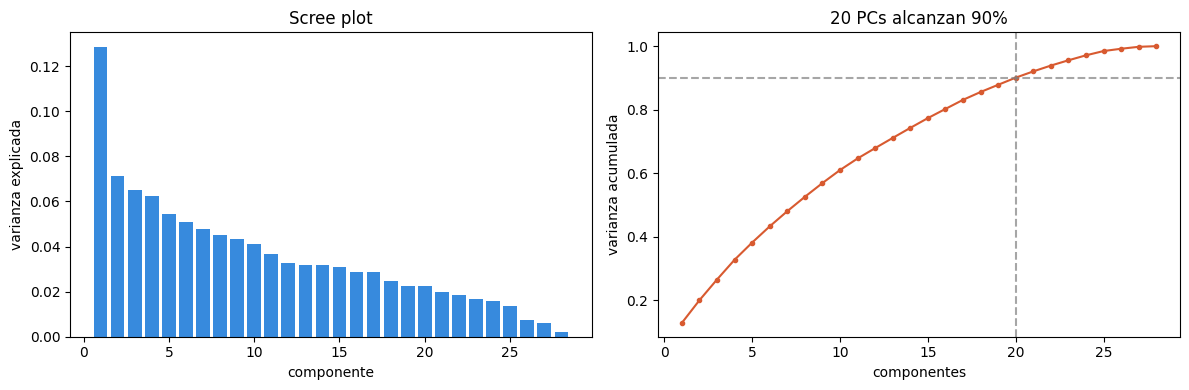

20

In [0]:
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

features = load_mod('features')
dimred = load_mod('dimensionality_reduction')

X, feat_names, biz_ids, biz_df = features.build_business_features(clean, top_categories=18)
print(f'Matriz de features: {X.shape[0]:,} negocios x {X.shape[1]} dimensiones\n')

eigvals, eigvecs, evr = dimred.pca_fit(X)
k90 = dimred.n_components_for(evr, target=0.90)
dimred.plot_scree(evr, target=0.90)

El resultado es deliberadamente poco espectacular: hacen falta 20 de 28 componentes para llegar al 90% y el scree decae de forma gradual, sin codo. Eso no es un fallo de PCA, es un hallazgo: las 28 features están poco correlacionadas entre sí (los 18 dummies de categoría son casi ortogonales por construcción), así que la varianza está repartida y no hay redundancia que comprimir. En este dataset PCA vale menos como compresor y más como (1) validación de que las features aportan información independiente y (2) generador de ejes interpretables, que leemos a continuación.

In [0]:
# sanity check: nuestro PCA debe coincidir con la SVD de la matriz centrada
import numpy as np
_, S_check, _ = np.linalg.svd(X - X.mean(0), full_matrices=False)
evr_svd = S_check**2 / (S_check**2).sum()
assert np.allclose(np.cumsum(evr)[:10], np.cumsum(evr_svd)[:10], atol=1e-8)
print('PCA propio == SVD de numpy: OK')

PCA propio == SVD de numpy: OK


### Interpretacion: que variables cargan en cada componente

Los *loadings* (coordenadas de los eigenvectores) dicen que combinacion de variables originales es cada PC. El signo indica direccion: dos variables con signos opuestos en la misma PC se mueven en sentidos contrarios a lo largo de ese eje.

In [0]:
dimred.loadings_table(eigvecs, evr, feat_names, n_pc=5, top=6)

,PC,var_explicada,top_variables
0,PC1,12.9%,"log_checkins (+0.40), cat::Restaurants (+0.39)..."
1,PC2,7.1%,"cat::Nightlife (-0.42), cat::Bars (-0.42), n_c..."
2,PC3,6.5%,"cat::Shopping (+0.41), cat::Fashion (+0.34), c..."
3,PC4,6.2%,"stars (-0.42), business_age (+0.37), avg_rev_l..."
4,PC5,5.4%,"cat::Event Planning & Services (+0.42), cat::H..."


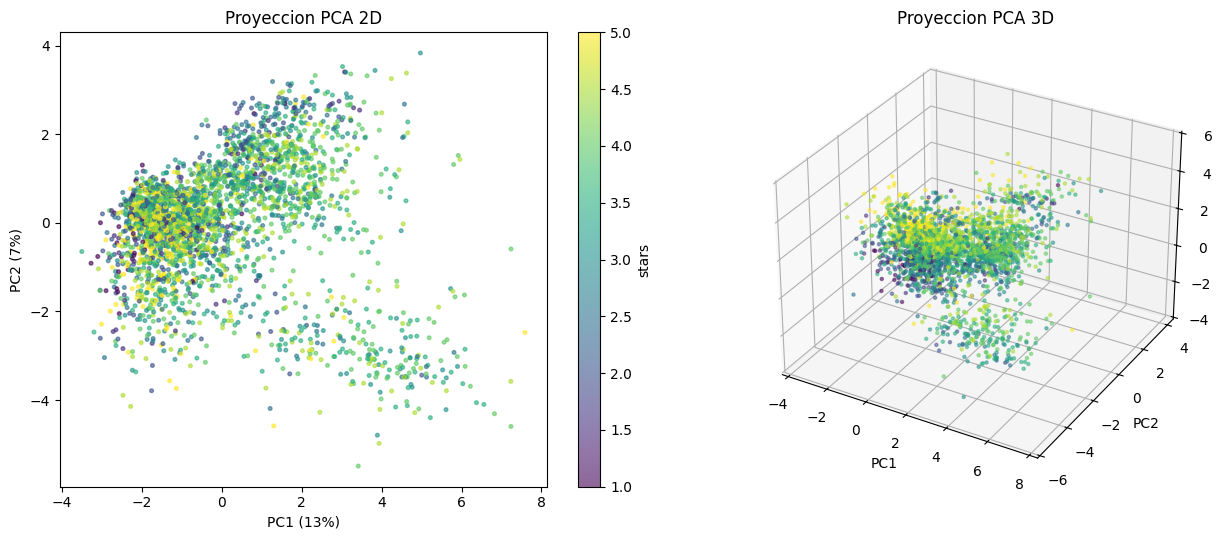

In [0]:
# proyeccion 2D/3D coloreada por rating del negocio
P = dimred.pca_project(X, eigvecs, max(k90, 3))
dimred.plot_projection(P, biz_df['stars'].to_numpy(), 'stars', evr)

En esta corrida se necesitan **20 de 28 componentes para el 90% de la varianza**: las features estan poco correlacionadas entre si (los dummies de categoria son casi ortogonales), asi que no hay una compresion drastica, pero las primeras PCs si son legibles:

- **PC1 (12.9%)** junta popularidad y gastronomia: log_checkins, cat::Restaurants, log_reviews, cat::Bars y cat::Nightlife cargan todas positivo -- el eje "negocio gastronomico concurrido".
- **PC2 (7.1%)** opone nightlife/bars (negativo) a coffee & tea (positivo): dentro de la gastronomia, bar nocturno vs cafeteria.
- **PC3 (6.5%)** es el eje shopping/fashion/food con stars positivo: comercio minorista bien calificado.
- **PC4 (6.2%)** es el eje **calidad/polarizacion**: stars carga negativo contra business_age, avg_rev_len y rating_std positivos -- negocios viejos, polarizados y con resenas largas vs jovenes bien calificados.

La proyeccion 2D muestra franjas/manchas por familia de categorias -- coherente con lo que K-Means y DBSCAN encontraron en la Parte III -- y el gradiente de color muestra donde viven los negocios mejor calificados.

### SVD sobre la matriz TF-IDF de resenas

Ahora la matriz es de verdad de alta dimension: cada negocio como documento (concatenacion de hasta 50 resenas) sobre un vocabulario de 2,000 terminos. `M = U S V^T`:

- las filas de `V^T` son direcciones en el espacio de terminos -> **temas latentes**;
- `U S` da las coordenadas de cada negocio en esos temas;
- truncar a `k` factores da la mejor aproximacion de rango `k` (teorema de Eckart-Young), con error `||M - M_k||_F / ||M||_F = sqrt(sum_{i>k} s_i^2 / sum_i s_i^2)` calculable directo de los valores singulares.

TF-IDF: 2,943 negocios x 2,000 terminos
SVD: M 2,943x2,000 -> 2000 valores singulares (s1=1.18, s2=0.88, ...)


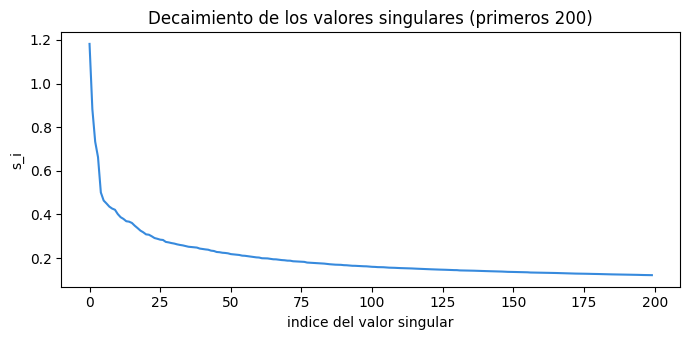

In [0]:
M, vocab = dimred.build_tfidf(clean['reviews'], list(biz_df['business_id']),
                              max_reviews_per_item=50, vocab_size=2000)
U, S, Vt = dimred.svd_fit(M)

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 3.5))
plt.plot(S[:200], color='#378ADD')
plt.xlabel('indice del valor singular'); plt.ylabel('s_i')
plt.title('Decaimiento de los valores singulares (primeros 200)')
plt.tight_layout(); plt.show()

In [0]:
# temas latentes: terminos dominantes de los primeros factores
dimred.latent_factors(Vt, vocab, n_factors=8, top=8)

,factor,terminos_dominantes
0,1,"pizza, food, chicken, hair, car, store, order,..."
1,2,"pizza, hair, salon, crust, car, delivery, wing..."
2,3,"hair, salon, pizza, food, cut, chicken, color,..."
3,4,"hair, salon, car, food, chicken, pizza, tacos,..."
4,5,"car, tacos, pool, store, vehicle, coffee, wash..."
5,6,"car, coffee, doctor, tacos, office, store, mex..."
6,7,"pool, store, hotel, car, bar, room, tacos, bre..."
7,8,"tacos, mexican, taco, pool, hotel, burger, fri..."


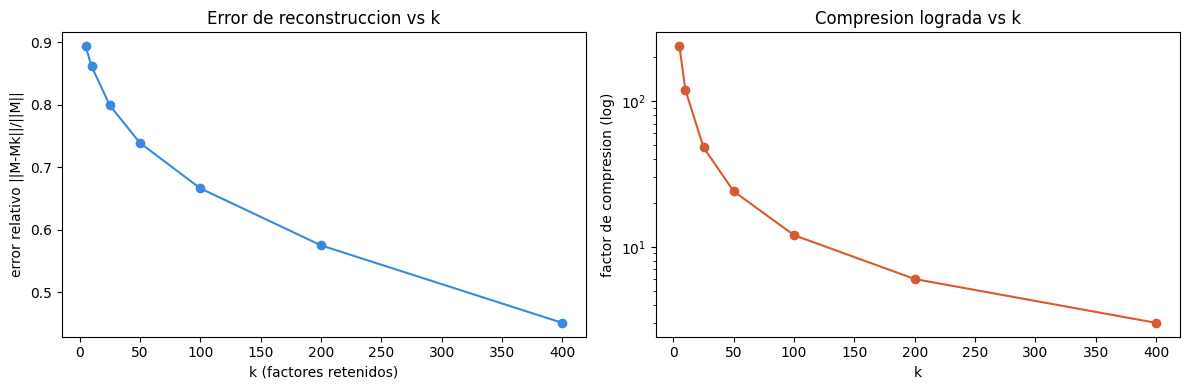

,k,error_relativo,varianza_capturada,celdas_almacenadas,compresion
0,5,0.8938,0.2010,24720,238x
1,10,0.8613,0.2582,49440,119x
2,25,0.7991,0.3615,123600,48x
3,50,0.7389,0.4540,247200,24x
4,100,0.6661,0.5563,494400,12x
5,200,0.5748,0.6696,988800,6x
6,400,0.4506,0.7969,1977600,3x


In [0]:
# compresion vs perdida: truncamos a k y medimos error de reconstruccion
rec = dimred.reconstruction_curve(M, U, S, Vt, ks=[5, 10, 25, 50, 100, 200, 400])
dimred.plot_reconstruction(rec)
rec

### Conclusiones de la parte de dimensionalidad

- **PCA** necesita 20 de 28 componentes para retener el 90% de la varianza (compresion moderada: los dummies de categoria aportan direcciones casi independientes), pero los loadings hacen el resultado interpretable: el primer eje es *popularidad gastronomica*, luego vienen ejes de *tipo de negocio* (bar vs cafeteria, shopping) y el eje de *calidad/polarizacion*. Ademas validamos la implementacion propia contra la SVD de numpy.
- **SVD sobre TF-IDF** encuentra temas latentes legibles: los primeros factores mezclan los dominios dominantes del corpus (pizza/comida, hair/salon, car/automotriz, tacos/mexicana, hotel/pool), es decir, el texto de las resenas recupera solo el tipo de negocio. La curva de reconstruccion cuantifica el tradeoff compresion/informacion: con k=100 factores (compresion 12x) se captura el 56% de la varianza, y con k=400 (3x) el 80%. El decaimiento gradual dice que el corpus es tematicamente diverso: no hay 5 temas que lo expliquen todo, pero unos cientos de factores bastan frente a 2,000 terminos -- la hipotesis detras de LSA y de los recomendadores de factores latentes.
- Diferencia clave entre ambas: PCA opera sobre features **densas y disenadas a mano** (covarianza interpretable variable a variable), mientras la SVD trabaja la matriz **rala y de alta dimension** del texto, donde la nocion util no es "varianza de una variable" sino "estructura de bajo rango".